<a href="https://colab.research.google.com/github/easare377/Prithvi-EO-Segmentation/blob/main/Training_and_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import essential libraries for data manipulation, model building, and visualization.

In [ ]:
!pip install terratorch

In [1]:
import numpy as np
import os

In [2]:

import requests
from tqdm import tqdm

def download_file(url, dest_path, chunk_size=1024*1024):
    """
    Download a large file from a URL with a progress bar.
    Args:
        url (str): File URL.
        dest_path (str): Destination file path.
        chunk_size (int): Download chunk size in bytes.
    """
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(dest_path, 'wb') as file, tqdm(
        desc=f"Downloading {dest_path}",
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=chunk_size):
            size = file.write(data)
            bar.update(size)


In [83]:
train_file_path = r'D:\ssm_footprint_train.tfrecord'
val_file_path = r'D:\ssm_2019_footprint_val.tfrecord'
# Create the directory if it doesn't exist
# train_dir = os.path.dirname(train_file_path)
# if not os.path.exists(train_dir):
#     os.makedirs(train_dir)
# val_dir = os.path.dirname(val_file_path)
# if not os.path.exists(val_dir):
#     os.makedirs(val_dir)

In [ ]:

#download_file("https://sco-training.s3.us-east-2.amazonaws.com/ssm_footprint_train.tfrecord", train_file_path)

In [ ]:
# Create the directory if it doesn't exist

#download_file("https://sco-training.s3.us-east-2.amazonaws.com/ssm_footprint_val.tfrecord", val_file_path)

In [2]:
def zero_pad_array(input_array, new_shape):
    """
    Zero-pad the input_array to the specified new_shape.
    Args:
        input_array (numpy.ndarray): Input array of shape (height, width, ...).
        new_shape (tuple): Desired new shape (new_height, new_width, ...).
    Returns:
        numpy.ndarray: Zero-padded array of shape (new_height, new_width, ...).
    """
    h, w = input_array.shape[:2]
    new_h, new_w = new_shape[:2]
    pad_h = max(new_h - h, 0)
    pad_w = max(new_w - w, 0)
    pad_values = [(0, pad_h), (0, pad_w)]
    pad_values += [(0, 0)] * (input_array.ndim - 2)
    return np.pad(input_array, pad_values, mode='constant', constant_values=0)


Implement a PyTorch Dataset for loading images and masks from NPZ files, including normalization and padding.


Implement a PyTorch Dataset for loading images and masks from TFRecord files, including normalization and padding.

In [3]:
import os, struct
import numpy as np
import tensorflow as tf
import torch
from torch.utils.data import Dataset
import random

def _zero_pad_hw(arr_hw_or_hwc, target_hw):
    th, tw = target_hw
    if arr_hw_or_hwc.ndim == 2:
        h, w = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)))
    else:
        h, w, c = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)),
               (0,0))
    return np.pad(arr_hw_or_hwc, pad, mode='constant')

def _zero_pad_cthw(X, target_hw):
    # pad only H,W for (C,T,H,W)
    C,T,H,W = X.shape
    img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)      # (H,W,C*T)
    img = _zero_pad_hw(img, target_hw)
    H2, W2, CT = img.shape
    img = np.transpose(img, (2,0,1)).reshape(C, T, H2, W2)
    return img

class MineFootprintTFRecordDataset(Dataset):
    # Your 6-band stats; if C != 6 we fall back to per-sample normalization
    MEAN = np.array([1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0], dtype=np.float32)
    STD  = np.array([2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0], dtype=np.float32)

    _feature_desc = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw":  tf.io.FixedLenFeature([], tf.string),
        "height":    tf.io.FixedLenFeature([], tf.int64),
        "width":     tf.io.FixedLenFeature([], tf.int64),
        "channels":  tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.VarLenFeature(tf.float32),  # length = 2*T
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    }

    def __init__(self, tfrecord_file, transform=None, pad_to=(224, 224)):
        super().__init__()
        self.tfrecord_path = os.fspath(tfrecord_file)
        self.transform = transform
        self.pad_to = pad_to
        self._offsets = self._scan_index()
        self._fh = open(self.tfrecord_path, 'rb')

    def _scan_index(self):
        offsets = []
        with open(self.tfrecord_path, 'rb') as f:
            pos = 0
            while True:
                header = f.read(12)                  # 8 len + 4 len_crc
                if not header:
                    break
                rec_len = struct.unpack('<Q', header[:8])[0]
                offsets.append(pos)
                pos += 12 + rec_len + 4             # header + data + data_crc
                f.seek(pos)
        return offsets

    def _read_record(self, offset):
        self._fh.seek(offset)
        header = self._fh.read(12)
        rec_len = struct.unpack('<Q', header[:8])[0]
        data = self._fh.read(rec_len)
        _ = self._fh.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _normalize_cthw(self, X):
        C,T,H,W = X.shape
        if C == len(self.MEAN):
            mean = self.MEAN.reshape(C,1,1,1)
            std  = (self.STD + 1e-6).reshape(C,1,1,1)
            return (X - mean) / std
        # Fallback: per-sample per-channel across (T,H,W)
        m = X.mean(axis=(1,2,3), keepdims=True)
        s = X.std(axis=(1,2,3), keepdims=True) + 1e-6
        return (X - m) / s

    def _apply_albu_over_time(self, X, mask):
        """Apply Albumentations over (H,W) consistently for all time steps:
           reshape (C,T,H,W) -> (H,W,C*T), apply, then back."""
        C,T,H,W = X.shape
        img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)   # (H,W,C*T)

        aug = self.transform(image=img, mask=mask)
        img_aug, msk_aug = aug["image"], aug["mask"]

        # Handle ToTensorV2 in pipeline
        if isinstance(img_aug, torch.Tensor):
            # Albumentations returns CHW if ToTensorV2; convert to HWC
            img_aug = img_aug.cpu().numpy().transpose(1,2,0)
        if isinstance(msk_aug, torch.Tensor):
            msk_aug = msk_aug.cpu().numpy()

        H2, W2, CT2 = img_aug.shape
        if CT2 % C != 0:
            raise RuntimeError(f"Aug channels {CT2} not divisible by C={C}")
        T2 = CT2 // C
        X2 = np.transpose(img_aug, (2,0,1)).reshape(C, T2, H2, W2)
        return X2, msk_aug

    def __getitem__(self, idx):
        serialised = self._read_record(self._offsets[idx])
        ex = tf.io.parse_single_example(serialised, self._feature_desc)

        H = int(ex["height"])
        W = int(ex["width"])
        C = int(ex["channels"])
        T = int(ex["timesteps"])

        img = np.frombuffer(ex["image_raw"].numpy(), dtype=np.float32).reshape((C, T, H, W))
        msk = np.frombuffer(ex["mask_raw"].numpy(),  dtype=np.uint8).reshape((H, W))

        img = np.nan_to_num(img, nan=0.0)
        msk = np.nan_to_num(msk.astype(np.float32), nan=0.0).astype(np.uint8)

        # Normalize per channel (broadcast over T,H,W)
        img = self._normalize_cthw(img)

        # Center-pad to target size
        img = _zero_pad_cthw(img, self.pad_to)       # (C,T,H2,W2)
        msk = _zero_pad_hw(msk, self.pad_to)         # (H2,W2)

        # Temporal/Location coords
        temporal_coords = tf.sparse.to_dense(ex["temporal_coords"]).numpy().astype(np.float32).reshape(T, 2)
        location_coords = ex["location_coords"].numpy().astype(np.float32)   # (2,)

        # Optional Albumentations over time (geom only)
        if self.transform is not None:
            img, msk = self._apply_albu_over_time(img, msk)

        # To torch
        img = torch.from_numpy(img).float()                  # (C,T,H,W)
        msk = torch.from_numpy(msk).long()                   # (H,W)
        temporal_coords = torch.from_numpy(temporal_coords)  # (T,2)
        location_coords = torch.from_numpy(location_coords)  # (2,)

        return {
            "image": img,  # (C,T,H,W)
            "temporal_coords": temporal_coords,  # (T,2)
            "location_coords": location_coords,  # (2,)
            "mask": msk      # (H,W)
        }

    def __del__(self):
        try:
            if hasattr(self, "_fh") and self._fh and not self._fh.closed:
                self._fh.close()
        except Exception:
            pass

# -------- collate: pick ONE random timestep length for the whole batch --------
def make_temporal_collate(max_T=10, min_T=1):
    assert 1 <= min_T <= max_T
    def _collate(batch):
        t_sel = 4 #random.randint(min_T, max_T)
        imgs, tcoords, lcoords, masks = [], [], [], []
        for sample in batch:
            X = sample["image"]                 # (C,T,H,W)
            T = X.shape[1]
            X = X[:, -t_sel:, :, :]             # keep LAST t_sel
            imgs.append(X)

            tc = sample["temporal_coords"]      # (T,2)
            tcoords.append(tc[-t_sel:, :])

            lcoords.append(sample["location_coords"])   # (2,)
            masks.append(sample["mask"])         # (H,W)

        imgs   = torch.stack(imgs,   dim=0)      # (B,C,t_sel,H,W)
        tcoords= torch.stack(tcoords,dim=0)      # (B,t_sel,2)
        lcoords= torch.stack(lcoords,dim=0)      # (B,2)
        masks  = torch.stack(masks,  dim=0)      # (B,H,W)
        return {"image": imgs,
                "temporal_coords": tcoords,
                "location_coords": lcoords,
                "mask": masks
               }
    return _collate

def make_temporal_collate(timesteps=4):
    #assert 1 <= min_T <= max_T
    def _collate(batch):
        t_sel = timesteps #random.randint(min_T, max_T)
        imgs, tcoords, lcoords, masks = [], [], [], []
        for sample in batch:
            X = sample["image"]                 # (C,T,H,W)
            T = X.shape[1]
            X = X[:, -t_sel:, :, :]             # keep LAST t_sel
            imgs.append(X)

            tc = sample["temporal_coords"]      # (T,2)
            tcoords.append(tc[-t_sel:, :])

            lcoords.append(sample["location_coords"])   # (2,)
            masks.append(sample["mask"])         # (H,W)

        imgs   = torch.stack(imgs,   dim=0)      # (B,C,t_sel,H,W)
        tcoords= torch.stack(tcoords,dim=0)      # (B,t_sel,2)
        lcoords= torch.stack(lcoords,dim=0)      # (B,2)
        masks  = torch.stack(masks,  dim=0)      # (B,H,W)
        return {"image": imgs,
                "temporal_coords": tcoords,
                "location_coords": lcoords,
                "mask": masks
               }
    return _collate


In [4]:
import os, struct
import numpy as np
import tensorflow as tf
import torch
from torch.utils.data import Dataset
import random

def _zero_pad_hw(arr_hw_or_hwc, target_hw):
    th, tw = target_hw
    if arr_hw_or_hwc.ndim == 2:
        h, w = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)))
    else:
        h, w, c = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)),
               (0,0))
    return np.pad(arr_hw_or_hwc, pad, mode='constant')

def _zero_pad_cthw(X, target_hw):
    C,T,H,W = X.shape
    img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)      # (H,W,C*T)
    img = _zero_pad_hw(img, target_hw)
    H2, W2, CT = img.shape
    img = np.transpose(img, (2,0,1)).reshape(C, T, H2, W2)
    return img

class MineFootprintTFRecordDataset(Dataset):
    MEAN = np.array([1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0], dtype=np.float32)
    STD  = np.array([2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0], dtype=np.float32)

    _feature_desc = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw":  tf.io.FixedLenFeature([], tf.string),
        "height":    tf.io.FixedLenFeature([], tf.int64),
        "width":     tf.io.FixedLenFeature([], tf.int64),
        "channels":  tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.VarLenFeature(tf.float32),  # length = 2*T
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    }

    def __init__(self, tfrecord_file, transform=None, pad_to=(224, 224)):
        super().__init__()
        self.tfrecord_path = os.fspath(tfrecord_file)
        self.transform = transform
        self.pad_to = pad_to
        self._offsets = self._scan_index()
        self._fh = open(self.tfrecord_path, 'rb')

    def _scan_index(self):
        offsets = []
        with open(self.tfrecord_path, 'rb') as f:
            pos = 0
            while True:
                header = f.read(12)
                if not header:
                    break
                rec_len = struct.unpack('<Q', header[:8])[0]
                offsets.append(pos)
                pos += 12 + rec_len + 4
                f.seek(pos)
        return offsets

    def _read_record(self, offset):
        self._fh.seek(offset)
        header = self._fh.read(12)
        rec_len = struct.unpack('<Q', header[:8])[0]
        data = self._fh.read(rec_len)
        _ = self._fh.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _apply_albu_over_time(self, X, mask):
        """Apply Albumentations over (H,W) consistently for all T."""
        C,T,H,W = X.shape
        img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)   # (H,W,C*T)

        aug = self.transform(image=img, mask=mask)
        img_aug, msk_aug = aug["image"], aug["mask"]

        # Handle ToTensorV2 in pipeline
        if isinstance(img_aug, torch.Tensor):
            img_aug = img_aug.cpu().numpy().transpose(1,2,0)
        if isinstance(msk_aug, torch.Tensor):
            msk_aug = msk_aug.cpu().numpy()

        H2, W2, CT2 = img_aug.shape
        if CT2 % C != 0:
            raise RuntimeError(f"Aug channels {CT2} not divisible by C={C}")
        T2 = CT2 // C
        X2 = np.transpose(img_aug, (2,0,1)).reshape(C, T2, H2, W2)
        return X2, msk_aug

    def __getitem__(self, idx):
        serialised = self._read_record(self._offsets[idx])
        ex = tf.io.parse_single_example(serialised, self._feature_desc)

        H = int(ex["height"]); W = int(ex["width"])
        C = int(ex["channels"]); T = int(ex["timesteps"])

        img = np.frombuffer(ex["image_raw"].numpy(), dtype=np.float32).reshape((C, T, H, W))
        msk = np.frombuffer(ex["mask_raw"].numpy(),  dtype=np.uint8).reshape((H, W))

        img = np.nan_to_num(img, nan=0.0)
        msk = np.nan_to_num(msk.astype(np.float32), nan=0.0).astype(np.uint8)

        # -------- NEW: build temporal_mask BEFORE normalization ---------------
        # frame is real if any pixel is non-zero across channels
        frame_energy = img.sum(axis=(0,2,3))            # (T,)
        temporal_mask = (frame_energy > 0).astype(np.float32)  # 1=real, 0=padded

        # -------- normalize ONLY real frames; keep padded frames at exact zero
        if C == len(self.MEAN):
            mean = self.MEAN.reshape(C,1,1,1)
            std  = (self.STD + 1e-6).reshape(C,1,1,1)
        else:
            # per-sample fallback (across T,H,W for each channel) using only real frames
            if temporal_mask.any():
                real = img[:, temporal_mask.astype(bool), :, :]
                mean = real.mean(axis=(1,2,3), keepdims=True)
                std  = real.std(axis=(1,2,3), keepdims=True) + 1e-6
            else:
                mean = np.zeros((C,1,1,1), dtype=np.float32)
                std  = np.ones((C,1,1,1), dtype=np.float32)

        img_norm = (img - mean) / std
        # zero-out padded frames again
        if (temporal_mask == 0).any():
            padded_idx = np.where(temporal_mask == 0)[0]
            img_norm[:, padded_idx, :, :] = 0.0
        img = img_norm
        # ---------------------------------------------------------------------

        # Center-pad to target size
        img = _zero_pad_cthw(img, self.pad_to)   # (C,T,H2,W2)
        msk = _zero_pad_hw(msk, self.pad_to)     # (H2,W2)

        # coords
        temporal_coords = tf.sparse.to_dense(ex["temporal_coords"]).numpy().astype(np.float32).reshape(T, 2)
        location_coords = ex["location_coords"].numpy().astype(np.float32)   # (2,)

        # Optional Albumentations (geom only) — preserves zeros for padded frames
        if self.transform is not None:
            img, msk = self._apply_albu_over_time(img, msk)

        # To torch
        img = torch.from_numpy(img).float()                         # (C,T,H,W)
        msk = torch.from_numpy(msk).long()                          # (H,W)
        temporal_coords = torch.from_numpy(temporal_coords)         # (T,2)
        location_coords = torch.from_numpy(location_coords)         # (2,)
        temporal_mask_t = torch.from_numpy(temporal_mask).float()   # (T,)

        return {
            "image": img,
            "temporal_coords": temporal_coords,
            "location_coords": location_coords,
            "temporal_mask": temporal_mask_t,   # <—— NEW
            "mask": msk
        }

    def __del__(self):
        try:
            if hasattr(self, "_fh") and self._fh and not self._fh.closed:
                self._fh.close()
        except Exception:
            pass


def make_temporal_collate(timesteps=4):
    def _collate(batch):
        t_sel = timesteps
        imgs, tcoords, lcoords, tmasks, masks = [], [], [], [], []
        for sample in batch:
            X  = sample["image"]                 # (C,T,H,W)
            tc = sample["temporal_coords"]       # (T,2)
            tm = sample["temporal_mask"]         # (T,)
            lc = sample["location_coords"]       # (2,)
            ms = sample["mask"]                  # (H,W)

            X  = X[:, -t_sel:, :, :]
            tc = tc[-t_sel:, :]
            tm = tm[-t_sel:]

            imgs.append(X)
            tcoords.append(tc)
            tmasks.append(tm)
            lcoords.append(lc)
            masks.append(ms)

        imgs    = torch.stack(imgs,    dim=0)  # (B,C,t_sel,H,W)
        tcoords = torch.stack(tcoords, dim=0)  # (B,t_sel,2)
        tmasks  = torch.stack(tmasks,  dim=0)  # (B,t_sel)
        lcoords = torch.stack(lcoords, dim=0)  # (B,2)
        masks   = torch.stack(masks,   dim=0)  # (B,H,W)

        return {
            "image": imgs,
            "temporal_coords": tcoords,
            "temporal_mask": tmasks,       # <—— pass to model if you support mask tokens
            "location_coords": lcoords,
            "mask": masks
        }
    return _collate


Set up an Albumentations transformation pipeline for data augmentation during training.

In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
# Define transformation pipeline
transform = A.Compose([
    A.RandomRotate90(p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    ToTensorV2(),
])

# Prepare Training Dataset and DataLoader
Initialize the training dataset and DataLoader for batch processing and shuffling.

# Prepare TFRecord Training Dataset and DataLoader
Initialize the TFRecord-based training dataset and DataLoader for batch processing and shuffling.

In [6]:
TIMESTEPS = 4
train_dataset = MineFootprintTFRecordDataset(train_file_path, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True,drop_last=True, collate_fn=make_temporal_collate(TIMESTEPS))

In [84]:
val_dataset = MineFootprintTFRecordDataset(val_file_path, transform=transform)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=False, drop_last=True, collate_fn=make_temporal_collate(TIMESTEPS))

In [85]:
len(val_dataset)

2016

In [35]:
#Print the shape of the training data
for batch in train_loader:
    x = batch["image"]               # (B,C,t',H,W)
    tcoords = batch["temporal_coords"] # (B,t',2)
    lcoords = batch["location_coords"] # (B,2)
    tmasks = batch["temporal_mask"]    # (B,t')
    y = batch["mask"]                  # (B,H,W)

    print("Batch image shape:", x.shape)
    print("Batch temporal coords shape:", tcoords.shape)
    print("Batch location coords shape:", lcoords.shape)
    print("Batch temporal masks shape:", tmasks.shape)
    print("Batch mask shape:", y.shape)
    break  # Just print the first batch

Batch image shape: torch.Size([2, 6, 4, 224, 224])
Batch temporal coords shape: torch.Size([2, 4, 2])
Batch location coords shape: torch.Size([2, 2])
Batch temporal masks shape: torch.Size([2, 4])
Batch mask shape: torch.Size([2, 224, 224])


In [10]:
import random, math
import numpy as np
import torch
import matplotlib.pyplot as plt

def visualize_random_temporal_rgb(
    ds,
    idx: int | None = None,
    rgb_indices=(2, 1, 0),      # (R,G,B) from your band order [BLUE,GREEN,RED,NIR_NARROW,SWIR_1,SWIR_2]
    scale_divisor: float = 3000.0,
    max_cols: int = 5,
    figsize=(16, 6),
    title: str | None = None,
):
    """
    Visualize RGB for each timestep (including zero-padded frames) from MineFootprintTFRecordDataset.

    - Picks a random index if `idx` is None.
    - Un-normalizes using ds.MEAN / ds.STD (expects shape (6,)).
    - Then scales by (img / scale_divisor) * 255 → uint8 for display.
    - Uses temporal_coords to label each frame; [0,0] will be marked as 'padded'.

    Args:
        ds: MineFootprintTFRecordDataset instance
        idx: optional dataset index; if None, a random one is chosen
        rgb_indices: channel indices for R,G,B within the C dimension
        scale_divisor: values divided by this, then mapped to 0..255
        max_cols: maximum columns in the subplot grid
        figsize: matplotlib figure size
        title: optional figure title
    """
    assert hasattr(ds, "MEAN") and hasattr(ds, "STD"), "Dataset must expose MEAN and STD."
    if idx is None:
        idx = random.randrange(len(ds))

    sample = ds[idx]  # {'image': (C,T,H,W) float, 'temporal_coords': (T,2), 'mask': (H,W), ...}

    X = sample["image"]            # torch.Tensor (C,T,H,W)
    tc = sample["temporal_coords"] # torch.Tensor (T,2)

    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(tc, torch.Tensor):
        tc = tc.detach().cpu().numpy()

    C, T, H, W = X.shape

    # ---- unnormalize (inverse of (x - mean) / std) ----
    mean = np.asarray(ds.MEAN, dtype=np.float32).reshape(-1, 1, 1, 1)
    std  = (np.asarray(ds.STD,  dtype=np.float32) + 1e-6).reshape(-1, 1, 1, 1)
    if mean.shape[0] != C:
        # Fallback: per-sample stats over (T,H,W) if band count differs
        m = X.mean(axis=(1,2,3), keepdims=True)
        s = X.std(axis=(1,2,3), keepdims=True) + 1e-6
        X_unnorm = X * s + m
    else:
        X_unnorm = X * std + mean

    # ---- prepare plotting grid ----
    ncols = min(T, max_cols)
    nrows = math.ceil(T / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for t in range(T):
        ax = axes[t]
        # Extract RGB per timestep
        r, g, b = rgb_indices
        rgb = np.stack([X_unnorm[r, t], X_unnorm[g, t], X_unnorm[b, t]], axis=-1)  # (H,W,3)

        # Scale to 0..255 via /3000
        rgb = np.clip(rgb / scale_divisor, 0.0, 1.0)
        rgb = (rgb * 255.0).round().astype(np.uint8)

        ax.imshow(rgb)
        ax.axis("off")

        year, doy = tc[t].tolist()
        if year == 0 and doy == 0:
            ax.set_title(f"T{t+1}: padded", fontsize=9)
        else:
            ax.set_title(f"T{t+1}: {int(year)} (doy={int(doy)})", fontsize=9)

    # Hide any extra axes
    for k in range(T, nrows * ncols):
        axes[k].axis("off")

    if title is None:
        title = f"Sample idx={idx}  |  C={C}, T={T}, H×W={H}×{W}"
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


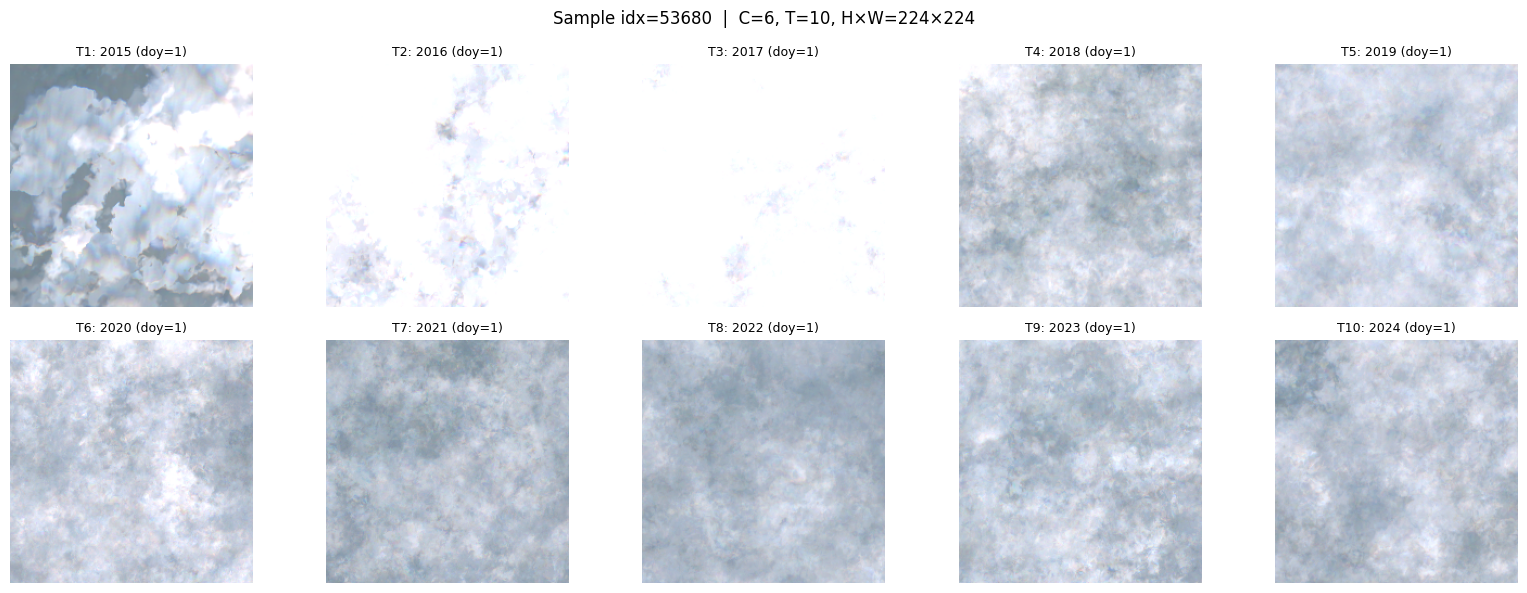

In [11]:
# Just call it with your dataset
visualize_random_temporal_rgb(train_dataset)  # random sample

# # Or pick a specific index
# visualize_random_temporal_rgb(train_dataset, idx=42, rgb_indices=(2,1,0))


# Define Semantic Segmentation Model
Create a semantic segmentation model using the TerraTorch library with a Prithvi EO backbone.

In [ ]:
from terratorch import BACKBONE_REGISTRY
# print just the Prithvi family (any registry)
prithvi_backbones = sorted([n for n in BACKBONE_REGISTRY if "prithvi" in n])
for backbone in prithvi_backbones:
    print(f"{backbone}")

## Prithvi Backbone Model Versions

| Model Name              | Size / Features     | Description                                                                 |
|-------------------------|--------------------|-----------------------------------------------------------------------------|
| Prithvi-EO-1.0-100M     | 100M parameters    | The original Prithvi-EO model (ViT backbone, 100M params), pretrained on US-only HLS data. |
| Prithvi-EO-2.0-100M     | 100M parameters    | Same architecture as 1.0-100M, but pretrained on a larger, global dataset.  |
| Prithvi-EO-2.0-300M     | 300M parameters    | Larger model, trained on global HLS data, without temporal/location embeddings. |
| Prithvi-EO-2.0-300M-TL  | 300M + Temp/Loc    | Same as above but with temporal and location embeddings.                     |
| Prithvi-EO-2.0-600M     | 600M parameters    | Even larger model, trained on global data, without temporal/location embeddings. |
| Prithvi-EO-2.0-600M-TL  | 600M + Temp/Loc    | Largest model, with both temporal and location embeddings included.          |


# Load Pretrained Model Weights
Load pretrained weights into the segmentation model for transfer learning or evaluation.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# assumes PrithviViT and FCNDecoder are imported from your source above
# from your_module import PrithviViT, FCNDecoder, get_3d_sincos_pos_embed
from terratorch.models.backbones.prithvi_mae import PrithviViT, get_3d_sincos_pos_embed
from terratorch.models.decoders import FCNDecoder


# ---------- helpers -----------------------------------------------------------
def set_temporal_frames(encoder: PrithviViT, T: int):
    """Make the encoder expect T frames and rebuild its pos_embed on the right device/dtype."""
    ps_t, ps_h, ps_w = encoder.patch_embed.patch_size
    assert ps_t == 1, f"temporal patch must be 1, got {ps_t}"
    encoder.num_frames = T
    encoder.patch_embed.input_size = (T,) + encoder.img_size
    encoder.patch_embed.grid_size  = [s // p for s, p in zip(encoder.patch_embed.input_size,
                                                             encoder.patch_embed.patch_size)]

    pos = get_3d_sincos_pos_embed(encoder.embed_dim, encoder.patch_embed.grid_size, add_cls_token=True)
    pos = torch.from_numpy(pos).float().unsqueeze(0).to(
        encoder.cls_token.device, dtype=encoder.cls_token.dtype
    )
    # replace buffer (non-persistent so it follows device moves cleanly)
    encoder.register_buffer("pos_embed", pos, persistent=False)


def patch_pos_interp_device_safety(encoder: PrithviViT):
    """
    Some builds return CPU tensors from interpolate_pos_encoding; make sure they land on the buffer's device/dtype.
    """
    _old = encoder.interpolate_pos_encoding

    def _safe(sample_shape):
        out = _old(sample_shape)
        return out.to(encoder.pos_embed.device, dtype=encoder.pos_embed.dtype)

    encoder.interpolate_pos_encoding = _safe  # bind to instance


# ---------- model -------------------------------------------------------------
class PrithviFCNSeg(nn.Module):
    """
    PrithviViT encoder -> token-to-image reshape -> FCNDecoder -> 1x1 head.

    Forward expects:
        x: (B, C, T, H, W) or (B, C, H, W) if T==1
        temporal_coords: (B, T, 2) or None
        location_coords: (B, 2) or None
    Returns:
        logits: (B, num_classes, H, W)
    """
    def __init__(
        self,
        encoder: PrithviViT,
        decoder: FCNDecoder,
        num_classes: int,
    ):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.head    = nn.Conv2d(decoder.out_channels, num_classes, kernel_size=1)

    def forward(self, x, temporal_coords=None, location_coords=None):
        B = x.shape[0]
        H, W = x.shape[-2], x.shape[-1]

        # 1) ViT features (list of token sequences, each with CLS token)
        feats = self.encoder.forward_features(
            x, temporal_coords=temporal_coords, location_coords=location_coords
        )  # list[Tensor], each [B, 1 + L, embed_dim]

        # 2) Minimal "neck": reshape tokens to (B, C*T, h, w) per level
        maps = self.encoder.prepare_features_for_image_model(feats)  # list[Tensor], e.g. last is [B, E*T, 14, 14]

        # 3) FCN decoder (expects list, picks in_index in its own forward)
        decoded = self.decoder(maps)               # (B, decoder_channels, Hdec, Wdec)

        # 4) 1x1 head to logits
        logits = self.head(decoded)                # (B, num_classes, Hdec, Wdec)

        # 5) Upsample back to input spatial size if needed
        if logits.shape[-2:] != (H, W):
            logits = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)

        return logits


# ---------- factory -----------------------------------------------------------
def build_prithvi_fcn_segmentation(
    *,
    num_classes: int = 3,
    in_chans: int = 6,
    img_size: int = 224,
    T: int = 10,
    patch_size=(1, 16, 16),
    embed_dim: int = 1024,
    depth: int = 24,
    num_heads: int = 16,
    mlp_ratio: float = 4.0,
    coords_encoding=("time", "location"),
    decoder_channels: int = 256,
    decoder_num_convs: int = 4,
    device: torch.device | str = "cuda",
):
    # 1) Encoder
    encoder = PrithviViT(
        img_size=img_size,
        patch_size=patch_size,  # (1,16,16) required for temporal encoding
        num_frames=T,
        in_chans=in_chans,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        coords_encoding=list(coords_encoding),
    )

    # Make pos-embed interpolation device-safe and lock T
    patch_pos_interp_device_safety(encoder)
    set_temporal_frames(encoder, T)

    # 2) Decoder: expects a list of embed_dims per stage; encoder.out_channels is already that list
    decoder = FCNDecoder(embed_dim=encoder.out_channels, channels=decoder_channels, num_convs=decoder_num_convs)

    # 3) Compose full model
    model = PrithviFCNSeg(encoder, decoder, num_classes=num_classes)
    return model.to(device)


c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from terratorch.models.backbones.prithvi_mae import PrithviViT, get_3d_sincos_pos_embed
# from terratorch.models.decoders import FCNDecoder

# # ---------- helpers -----------------------------------------------------------
# def set_temporal_frames(encoder: PrithviViT, T: int):
#     """Make the encoder expect T frames and rebuild its pos_embed on the right device/dtype."""
#     ps_t, ps_h, ps_w = encoder.patch_embed.patch_size
#     assert ps_t == 1, f"temporal patch must be 1, got {ps_t}"
#     encoder.num_frames = T
#     encoder.patch_embed.input_size = (T,) + encoder.img_size
#     encoder.patch_embed.grid_size  = [s // p for s, p in zip(encoder.patch_embed.input_size,
#                                                              encoder.patch_embed.patch_size)]

#     pos = get_3d_sincos_pos_embed(encoder.embed_dim, encoder.patch_embed.grid_size, add_cls_token=True)
#     pos = torch.from_numpy(pos).float().unsqueeze(0).to(
#         encoder.cls_token.device, dtype=encoder.cls_token.dtype
#     )
#     # replace buffer (non-persistent so it follows device moves cleanly)
#     encoder.register_buffer("pos_embed", pos, persistent=False)

# def patch_pos_interp_device_safety(encoder: PrithviViT):
#     """Make sure interpolate_pos_encoding returns tensors on the same device/dtype as encoder.pos_embed."""
#     _old = encoder.interpolate_pos_encoding
#     def _safe(sample_shape):
#         out = _old(sample_shape)
#         return out.to(encoder.pos_embed.device, dtype=encoder.pos_embed.dtype)
#     encoder.interpolate_pos_encoding = _safe  # bind to instance


# import torch
# import torch.nn as nn

# class TemporalMix(nn.Module):
#     """
#     Input:  (B, T*E, h, w)  from Prithvi.prepare_features_for_image_model
#     Output: (B, E,   h, w)  temporal-aggregated

#     mode='avg': simple mean over time (robust & cheap)
#     mode='depthwise': depthwise Conv3d (kernel over T) after re-shaping to (B,E,T,h,w)
#     """
#     def __init__(self, embed_dim_per_frame: int, T: int, mode="avg"):
#         super().__init__()
#         self.E = embed_dim_per_frame
#         self.T = T
#         self.mode = mode
#         if mode == "depthwise":
#             # Conv over T only, per-channel (depthwise)
#             self.dw = nn.Conv3d(self.E, self.E, kernel_size=(T,1,1),
#                                 stride=(1,1,1), groups=self.E, bias=False)
#         elif mode == "avg":
#             self.register_buffer("_dummy", torch.tensor(0))  # placeholder
#         else:
#             raise ValueError("mode must be 'avg' or 'depthwise'")

#     def forward(self, x):  # x: (B, T*E, h, w)
#         B, TE, h, w = x.shape
#         assert TE % self.E == 0, f"channels ({TE}) not multiple of E ({self.E})"
#         T = TE // self.E
#         x = x.view(B, T, self.E, h, w).permute(0,2,1,3,4)  # (B,E,T,h,w)
#         if self.mode == "avg":
#             x = x.mean(dim=2)                               # (B,E,h,w)
#         else:
#             x = self.dw(x)                                  # (B,E,1,h,w)
#             x = x.squeeze(2)                                # (B,E,h,w)
#         return x


# # ---------- masked wrapper around Prithvi -------------------------------------
# class MaskedPrithviEncoder(nn.Module):
#     """
#     Wraps a PrithviViT and adds temporal masking with a learnable mask token.
#     temporal_mask: (B, T) with 1=valid frame, 0=missing frame.
#     """
#     def __init__(self, base: PrithviViT):
#         super().__init__()
#         self.base = base
#         # one vector per token (same dim as encoder)
#         self.mask_token = nn.Parameter(torch.zeros(1, 1, base.embed_dim))
#         nn.init.trunc_normal_(self.mask_token, std=0.02)

#     @torch.no_grad()
#     def _tokens_per_frame(self, L: int) -> int:
#         # number of tokens per frame = spatial tokens per frame
#         t = self.base.num_frames
#         assert L % t == 0, f"L={L} not divisible by T={t}"
#         return L // t

#     def forward_features(self,
#                          x: torch.Tensor,
#                          temporal_coords: torch.Tensor | None = None,
#                          location_coords: torch.Tensor | None = None,
#                          temporal_mask: torch.Tensor | None = None) -> list[torch.Tensor]:
#         """
#         Exactly mirrors PrithviViT.forward_features, but inserts a masking step:
#         - After patch_embed and +pos/+coords
#         - Replace all tokens of frames where temporal_mask==0 with a learned mask token
#         """
#         base = self.base

#         # ensure a time dim if encoder uses T=1
#         if len(x.shape) == 4 and base.patch_embed.input_size[0] == 1:
#             x = x.unsqueeze(2)
#         sample_shape = x.shape[-3:]

#         # 1) patch embedding -> (B, L, D)
#         x = base.patch_embed(x)

#         # 2) positional/coord encodings
#         pos_embed = base.interpolate_pos_encoding(sample_shape)
#         x = x + pos_embed[:, 1:, :]  # no cls token yet

#         if base.temporal_encoding and temporal_coords is not None:
#             num_tokens_per_frame = x.shape[1] // base.num_frames
#             temporal_encoding = base.temporal_embed_enc(temporal_coords, num_tokens_per_frame)
#             x = x + temporal_encoding
#         if base.location_encoding and location_coords is not None:
#             location_encoding = base.location_embed_enc(location_coords)
#             x = x + location_encoding

#         # 3) temporal masking (our addition)
#         if temporal_mask is not None:
#             # temporal_mask: (B, T) -> broadcast to (B, T, tokens_per_frame, 1)
#             B, L, D = x.shape
#             T = base.num_frames
#             tpf = self._tokens_per_frame(L)               # tokens per frame
#             x = x.view(B, T, tpf, D)                      # (B,T,H*W,D)

#             # make sure mask is float on same device
#             m = temporal_mask.to(x.device).float().view(B, T, 1, 1)  # (B,T,1,1)
#             # where m==0, replace by mask_token
#             mask_tok = self.mask_token.to(x.dtype)        # (1,1,D)
#             x = m * x + (1.0 - m) * mask_tok              # broadcasting over tpf

#             x = x.view(B, T * tpf, D)                     # back to (B,L,D)

#         # 4) append cls token and pass through blocks
#         cls_token = base.cls_token + pos_embed[:, :1, :]
#         x = torch.cat((cls_token.expand(x.shape[0], -1, -1), x), dim=1)

#         out = []
#         for block in base.blocks:
#             x = block(x)
#             out.append(x.clone())  # keep per-block (like original)
#         x = base.norm(x)
#         out[-1] = x
#         return out

#     # keep the same utility used by TerraTorch pixel models
#     def prepare_features_for_image_model(self, features: list[torch.Tensor]) -> list[torch.Tensor]:
#         return self.base.prepare_features_for_image_model(features)

#     @property
#     def out_channels(self):
#         return self.base.out_channels

# # ---------- model -------------------------------------------------------------
# class PrithviFCNSeg(nn.Module):
#     """
#     Mask-aware PrithviViT encoder -> token-to-image reshape -> FCNDecoder -> 1x1 head.
#     Accepts optional temporal_mask (B,T) with 1/0 validity.
#     """
#     def __init__(self, encoder: MaskedPrithviEncoder, decoder: FCNDecoder, num_classes: int):
#         super().__init__()
#         self.encoder = encoder
#         self.decoder = decoder
#         self.head    = nn.Conv2d(decoder.out_channels, num_classes, kernel_size=1)

#     def forward(self, x, temporal_coords=None, location_coords=None, temporal_mask: torch.Tensor | None = None):
#         H, W = x.shape[-2], x.shape[-1]

#         feats = self.encoder.forward_features(
#             x, temporal_coords=temporal_coords, location_coords=location_coords, temporal_mask=temporal_mask
#         )  # list[Tensor], each [B, 1 + L, D]

#         maps = self.encoder.prepare_features_for_image_model(feats)  # list[Tensor], e.g. last is [B, E*T, 14, 14]
#         decoded = self.decoder(maps)               # (B, decoder_channels, Hdec, Wdec)
#         logits = self.head(decoded)                # (B, num_classes, Hdec, Wdec)

#         if logits.shape[-2:] != (H, W):
#             logits = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
#         return logits

# # ---------- factory -----------------------------------------------------------
# def build_prithvi_fcn_segmentation(
#     *,
#     num_classes: int = 3,
#     in_chans: int = 6,
#     img_size: int = 224,
#     T: int = 10,
#     patch_size=(1, 16, 16),
#     embed_dim: int = 1024,
#     depth: int = 24,
#     num_heads: int = 16,
#     mlp_ratio: float = 4.0,
#     coords_encoding=("time", "location"),
#     decoder_channels: int = 256,
#     decoder_num_convs: int = 4,
#     device: torch.device | str = "cuda",
# ):
#     # 1) base encoder
#     base = PrithviViT(
#         img_size=img_size,
#         patch_size=patch_size,  # (1,16,16) required for temporal encoding
#         num_frames=T,
#         in_chans=in_chans,
#         embed_dim=embed_dim,
#         depth=depth,
#         num_heads=num_heads,
#         mlp_ratio=mlp_ratio,
#         coords_encoding=list(coords_encoding),
#     )
#     patch_pos_interp_device_safety(base)
#     set_temporal_frames(base, T)

#     # 2) masked wrapper
#     encoder = MaskedPrithviEncoder(base)

#     # 3) FCN decoder (dim list is already in base.out_channels)
#     decoder = FCNDecoder(embed_dim=encoder.out_channels, channels=decoder_channels, num_convs=decoder_num_convs)

#     # after you get maps = encoder.prepare_features_for_image_model(feats)
#     # maps is a list, e.g. [lvl1, lvl2, ..., last] with shapes (B, T*E, h, w)
#     temporal_mixer = TemporalMix(embed_dim_per_frame=encoder.embed_dim, T=TIMESTEPS, mode="avg")

#     maps = [temporal_mixer(m) for m in maps]   # turn (B,T*E,h,w) -> (B,E,h,w) per level
#     decoder = decoder(maps)                # your 2D FCN (works)


#     model = PrithviFCNSeg(encoder, decoder, num_classes=num_classes)
#     return model.to(device)


In [8]:
import torch
import torch.nn as nn
import numpy as np
from typing import List

class MaskedPrithviEncoder(nn.Module):
    """
    Wraps a TerraTorch PrithviViT and adds support for temporal_mask in forward_features.

    temporal_mask: (B, T) with 1 for real frames, 0 for padded/missing frames.
    Strategy: zero-out token features for masked timesteps *after* embeddings are added,
              *before* transformer blocks, so they contribute minimally downstream.
    """
    def __init__(self, base_encoder: "PrithviViT"):
        super().__init__()
        self.encoder = base_encoder

    @torch.no_grad()
    def _tokens_per_frame(self, x_tokens: torch.Tensor) -> int:
        # x_tokens is [B, L, D] after patch_embed; L == T * (H/P * W/P)
        # T is effectively (input_T / patch_t); with patch_t==1 → tokens_per_frame = L / T
        eff_T = self.encoder.patch_embed.input_size[0] // self.encoder.patch_embed.patch_size[0]
        return x_tokens.shape[1] // eff_T  # tokens per frame

    def forward_features(
        self,
        x: torch.Tensor,
        temporal_coords: torch.Tensor | None = None,
        location_coords: torch.Tensor | None = None,
        temporal_mask: torch.Tensor | None = None,   # <—— NEW
    ) -> List[torch.Tensor]:
        enc = self.encoder

        # match library's shape handling
        if len(x.shape) == 4 and enc.patch_embed.input_size[0] == 1:
            x = x.unsqueeze(2)
        sample_shape = x.shape[-3:]  # (T, H, W)

        # 1) patch embedding: (B,C,T,H,W) -> (B,L,D)
        x = enc.patch_embed(x)

        # 2) position encoding (interpolated to current (T,H,W))
        pos_embed = enc.interpolate_pos_encoding(sample_shape)  # (1, 1+L, D)
        x = x + pos_embed[:, 1:, :]  # add patch pos emb

        # 3) optional temporal/location encodings
        if enc.temporal_encoding and (temporal_coords is not None):
            num_tokens_per_frame = self._tokens_per_frame(x)
            te = enc.temporal_embed_enc(temporal_coords, num_tokens_per_frame)  # (B, L, D)
            x = x + te
        if enc.location_encoding and (location_coords is not None):
            le = enc.location_embed_enc(location_coords)  # (B,1,D)
            x = x + le

        # 4) —— NEW: temporal mask → token mask → zero tokens of missing frames
        if temporal_mask is not None:
            # temporal_mask: (B, T_eff) in the same time length as current input
            # expand to per-token: each timestep has 'tokens_per_frame' tokens
            B, L, D = x.shape
            eff_T = enc.patch_embed.input_size[0] // enc.patch_embed.patch_size[0]
            assert temporal_mask.shape[1] == eff_T, f"temporal_mask T={temporal_mask.shape[1]} != {eff_T}"
            tpf = L // eff_T
            # (B,T,1) -> repeat along tokens-per-frame → (B, T*tpf) == (B, L)
            tok_mask = temporal_mask.unsqueeze(-1).repeat(1, 1, tpf).reshape(B, L)  # 1=keep, 0=pad
            x = x * tok_mask.unsqueeze(-1)  # zero out masked tokens

        # 5) prepend CLS
        cls = enc.cls_token + pos_embed[:, :1, :]
        x = torch.cat([cls.expand(x.shape[0], -1, -1), x], dim=1)

        # 6) transformer blocks (collect per-layer features like the library)
        out = []
        for blk in enc.blocks:
            x = blk(x)
            out.append(x.clone())

        x = enc.norm(x)
        out[-1] = x
        return out

    def prepare_features_for_image_model(self, features: list[torch.Tensor]) -> list[torch.Tensor]:
        # delegate to base encoder's neck reshaper
        return self.encoder.prepare_features_for_image_model(features)
    

import torch.nn.functional as F

class PrithviFCNSeg(nn.Module):
    def __init__(self, encoder_with_mask: MaskedPrithviEncoder, decoder: "FCNDecoder", num_classes: int):
        super().__init__()
        self.encoder = encoder_with_mask
        self.decoder = decoder
        self.head    = nn.Conv2d(decoder.out_channels, num_classes, kernel_size=1)

    def forward(self, x, temporal_coords=None, location_coords=None, temporal_mask=None):
        H, W = x.shape[-2], x.shape[-1]

        feats = self.encoder.forward_features(
            x,
            temporal_coords=temporal_coords,
            location_coords=location_coords,
            temporal_mask=temporal_mask,    # <—— pass it in
        )
        maps = self.encoder.prepare_features_for_image_model(feats)
        decoded = self.decoder(maps)
        logits  = self.head(decoded)
        if logits.shape[-2:] != (H, W):
            logits = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
        return logits

from terratorch.models.backbones.prithvi_mae import PrithviViT, get_3d_sincos_pos_embed
from terratorch.models.decoders import FCNDecoder

def set_temporal_frames(encoder: PrithviViT, T: int):
    ps_t, _, _ = encoder.patch_embed.patch_size
    assert ps_t == 1
    encoder.num_frames = T
    encoder.patch_embed.input_size = (T,) + encoder.img_size
    encoder.patch_embed.grid_size  = [s // p for s, p in zip(encoder.patch_embed.input_size,
                                                             encoder.patch_embed.patch_size)]
    pos = get_3d_sincos_pos_embed(encoder.embed_dim, encoder.patch_embed.grid_size, add_cls_token=True)
    pos = torch.from_numpy(pos).float().unsqueeze(0).to(encoder.cls_token.device, dtype=encoder.cls_token.dtype)
    encoder.register_buffer("pos_embed", pos, persistent=False)

def build_prithvi_fcn_segmentation(
    *,
    num_classes=3,
    in_chans=6,
    img_size=224,
    T=10,
    patch_size=(1,16,16),
    embed_dim=1024, depth=24, num_heads=16, mlp_ratio=4.0,
    coords_encoding=("time","location"),
    decoder_channels=256, decoder_num_convs=4,
    device="cuda",
):
    base_enc = PrithviViT(
        img_size=img_size,
        patch_size=patch_size,
        num_frames=T,
        in_chans=in_chans,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        coords_encoding=list(coords_encoding),
    )
    set_temporal_frames(base_enc, T)
    enc = MaskedPrithviEncoder(base_enc)

    dec = FCNDecoder(embed_dim=enc.encoder.out_channels, channels=decoder_channels, num_convs=decoder_num_convs)
    model = PrithviFCNSeg(enc, dec, num_classes=num_classes)
    return model.to(device)



c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import List

# ----------------------------- Temporal mix ----------------------------- #
class TemporalMix(nn.Module):
    """
    Turn (B, T*E, h, w) -> (B, E, h, w) by aggregating along time.

    mode='avg'        : simple mean over time (fast, robust)
    mode='depthwise'  : depthwise Conv3d over T (learned temporal kernel)
    """
    def __init__(self, embed_dim_per_frame: int, T: int, mode: str = "avg"):
        super().__init__()
        self.E = embed_dim_per_frame
        self.T = T
        self.mode = mode
        if mode == "depthwise":
            # expects (B,E,T,h,w)
            self.dw = nn.Conv3d(
                in_channels=self.E,
                out_channels=self.E,
                kernel_size=(T, 1, 1),     # full temporal window
                stride=(1, 1, 1),
                padding=(0, 0, 0),
                groups=self.E,
                bias=False,
            )
        elif mode == "avg":
            self.register_buffer("_dummy", torch.tensor(0))  # no params
        else:
            raise ValueError("TemporalMix.mode must be 'avg' or 'depthwise'")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T*E, h, w)
        B, TE, h, w = x.shape
        assert TE % self.E == 0, f"channels ({TE}) not multiple of E ({self.E})"
        T = TE // self.E
        x = x.view(B, T, self.E, h, w).permute(0, 2, 1, 3, 4)  # (B,E,T,h,w)

        if self.mode == "avg":
            x = x.mean(dim=2)                                   # (B,E,h,w)
        else:
            x = self.dw(x).squeeze(2)                           # (B,E,1,h,w)->(B,E,h,w)
        return x


# --------------------- Masked Prithvi encoder wrapper -------------------- #
class MaskedPrithviEncoder(nn.Module):
    """
    Wraps a TerraTorch PrithviViT and adds support for temporal_mask in forward_features.

    temporal_mask: (B, T) with 1 for real frames, 0 for padded/missing frames.
    We zero token features for masked timesteps *after* embeddings are added,
    *before* transformer blocks.
    """
    def __init__(self, base_encoder: "PrithviViT"):
        super().__init__()
        self.encoder = base_encoder

    @torch.no_grad()
    def _tokens_per_frame(self, x_tokens: torch.Tensor) -> int:
        eff_T = self.encoder.patch_embed.input_size[0] // self.encoder.patch_embed.patch_size[0]
        return x_tokens.shape[1] // eff_T  # tokens per frame

    def forward_features(
        self,
        x: torch.Tensor,
        temporal_coords: torch.Tensor | None = None,
        location_coords: torch.Tensor | None = None,
        temporal_mask: torch.Tensor | None = None,
    ) -> List[torch.Tensor]:
        enc = self.encoder

        if len(x.shape) == 4 and enc.patch_embed.input_size[0] == 1:
            x = x.unsqueeze(2)
        sample_shape = x.shape[-3:]  # (T,H,W)

        # (B,C,T,H,W) -> (B,L,D)
        x = enc.patch_embed(x)

        # pos enc (1,1+L,D), add to patches only
        pos_embed = enc.interpolate_pos_encoding(sample_shape)
        x = x + pos_embed[:, 1:, :]

        # optional temporal/location enc
        if enc.temporal_encoding and (temporal_coords is not None):
            num_tokens_per_frame = self._tokens_per_frame(x)
            te = enc.temporal_embed_enc(temporal_coords, num_tokens_per_frame)  # (B,L,D)
            x = x + te
        if enc.location_encoding and (location_coords is not None):
            le = enc.location_embed_enc(location_coords)  # (B,1,D)
            x = x + le

        # temporal mask -> token mask
        if temporal_mask is not None:
            B, L, D = x.shape
            eff_T = enc.patch_embed.input_size[0] // enc.patch_embed.patch_size[0]
            assert temporal_mask.dim() == 2 and temporal_mask.shape[0] == B, \
                f"temporal_mask must be (B,T), got {tuple(temporal_mask.shape)}"
            assert temporal_mask.shape[1] == eff_T, f"T_mask={temporal_mask.shape[1]} != eff_T={eff_T}"
            tpf = L // eff_T
            tok_mask = temporal_mask.unsqueeze(-1).repeat(1, 1, tpf).reshape(B, L)  # (B,L)
            x = x * tok_mask.unsqueeze(-1)

        # prepend CLS, run blocks (collect per-layer like TT)
        cls = enc.cls_token + pos_embed[:, :1, :]
        x = torch.cat([cls.expand(x.shape[0], -1, -1), x], dim=1)

        out = []
        for blk in enc.blocks:
            x = blk(x)
            out.append(x.clone())

        x = enc.norm(x)
        out[-1] = x
        return out

    def prepare_features_for_image_model(self, features: list[torch.Tensor]) -> list[torch.Tensor]:
        # returns list of (B, T*E, h, w)
        return self.encoder.prepare_features_for_image_model(features)


# --------------------------- Segmentation head --------------------------- #
class PrithviFCNSeg(nn.Module):
    """
    Encoder (masked) -> token->image (B,T*E,h,w) -> TemporalMix -> 2D FCN -> 1x1 head.
    """
    def __init__(
        self,
        encoder_with_mask: MaskedPrithviEncoder,
        decoder: "FCNDecoder",
        num_classes: int,
        temporal_mixer: TemporalMix,
    ):
        super().__init__()
        self.encoder = encoder_with_mask
        self.temporal_mixer = temporal_mixer
        self.decoder = decoder
        self.head = nn.Conv2d(decoder.out_channels, num_classes, kernel_size=1)

    def forward(self, x, temporal_coords=None, location_coords=None, temporal_mask=None):
        H, W = x.shape[-2], x.shape[-1]

        feats = self.encoder.forward_features(
            x,
            temporal_coords=temporal_coords,
            location_coords=location_coords,
            temporal_mask=temporal_mask,
        )
        # list of (B, T*E, h, w)
        maps = self.encoder.prepare_features_for_image_model(feats)

        # temporal aggregation per level -> (B, E, h, w)
        maps = [self.temporal_mixer(m) for m in maps]

        decoded = self.decoder(maps)    # (B, Cdec, h', w')
        logits  = self.head(decoded)    # (B, K,    h', w')

        if logits.shape[-2:] != (H, W):
            logits = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
        return logits


# ----------------------------- Builder utils ----------------------------- #
from terratorch.models.backbones.prithvi_mae import PrithviViT, get_3d_sincos_pos_embed
from terratorch.models.decoders import FCNDecoder

@torch.no_grad()
def set_temporal_frames(encoder: PrithviViT, T: int):
    ps_t, _, _ = encoder.patch_embed.patch_size
    assert ps_t == 1, f"temporal patch must be 1 (got {ps_t})"
    encoder.num_frames = T
    encoder.patch_embed.input_size = (T,) + encoder.img_size
    encoder.patch_embed.grid_size  = [s // p for s, p in zip(
        encoder.patch_embed.input_size, encoder.patch_embed.patch_size
    )]
    pos = get_3d_sincos_pos_embed(encoder.embed_dim, encoder.patch_embed.grid_size, add_cls_token=True)
    pos = torch.from_numpy(pos).float().unsqueeze(0).to(
        encoder.cls_token.device, dtype=encoder.cls_token.dtype
    )
    encoder.register_buffer("pos_embed", pos, persistent=False)


def build_prithvi_fcn_segmentation(
    *,
    num_classes=3,
    in_chans=6,
    img_size=224,
    T=10,
    patch_size=(1, 16, 16),
    embed_dim=1024, depth=24, num_heads=16, mlp_ratio=4.0,
    coords_encoding=("time", "location"),
    decoder_channels=256, decoder_num_convs=4,
    temporal_mix_mode: str = "avg",   # 'avg' or 'depthwise'
    device="cuda",
):
    # 1) base encoder
    base_enc = PrithviViT(
        img_size=img_size,
        patch_size=patch_size,
        num_frames=T,
        in_chans=in_chans,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        coords_encoding=list(coords_encoding),
    )
    set_temporal_frames(base_enc, T)
    enc = MaskedPrithviEncoder(base_enc)

    # 2) temporal mix (needs per-frame embed dim and effective T)
    eff_T = base_enc.patch_embed.grid_size[0]     # == T when patch_t == 1
    tmix = TemporalMix(embed_dim_per_frame=embed_dim, T=eff_T, mode=temporal_mix_mode)

    # 3) FCN decoder expects per-level input channels list
    #    After temporal mix, each level is (B, embed_dim, h, w)
    in_dims_for_decoder = [embed_dim] * depth
    dec = FCNDecoder(embed_dim=in_dims_for_decoder, channels=decoder_channels, num_convs=decoder_num_convs)

    # 4) compose
    model = PrithviFCNSeg(enc, dec, num_classes=num_classes, temporal_mixer=tmix)
    return model.to(device)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_prithvi_fcn_segmentation(
    num_classes=3,
    in_chans=6,
    img_size=224,
    T=TIMESTEPS,
    embed_dim=1024, depth=24, num_heads=16,
    decoder_channels=256, decoder_num_convs=4,
    temporal_mix_mode="avg",          # try "depthwise" after things are stable
    device=device,
)


In [ ]:
from __future__ import annotations
import math
from typing import List, Sequence, Tuple

import torch
from torch import nn, Tensor

try:
    # TerraTorch registry (mirrors your FCNDecoder setup)
    from terratorch.registry import TERRATORCH_DECODER_REGISTRY
except Exception:  # fallback so the file is still importable without TerraTorch
    class _DummyRegistry:
        def register(self, cls):
            return cls
    TERRATORCH_DECODER_REGISTRY = _DummyRegistry()


# ----------------------------
# Normalization helpers
# ----------------------------
class Norm3d(nn.Module):
    """Channel-wise LayerNorm for 5D tensors [B, C, T, H, W].
    (We use LN to stay consistent with ViT-style features.)
    """
    def __init__(self, channels: int):
        super().__init__()
        self.ln = nn.LayerNorm(channels, eps=1e-6)

    def forward(self, x: Tensor) -> Tensor:
        # x: [B, C, T, H, W] -> LN over C
        x = x.permute(0, 2, 3, 4, 1)  # [B, T, H, W, C]
        x = self.ln(x)
        x = x.permute(0, 4, 1, 2, 3).contiguous()
        return x


def _conv3d_upscale_block(
    in_ch: int,
    out_ch: int,
    *,
    k: Tuple[int, int, int] = (1, 2, 2),
    s: Tuple[int, int, int] = (1, 2, 2),
    d: Tuple[int, int, int] = (1, 1, 1),
    p: Tuple[int, int, int] = (0, 0, 0),
    op: Tuple[int, int, int] = (0, 0, 0),
) -> nn.Sequential:
    return nn.Sequential(
        nn.ConvTranspose3d(in_ch, out_ch, kernel_size=k, stride=s, dilation=d, padding=p, output_padding=op, bias=True),
        nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=True),
        Norm3d(out_ch),
        nn.GELU(),
    )


@TERRATORCH_DECODER_REGISTRY.register
class FCN3DDecoder(nn.Module):
    """
    Fully Convolutional **3D** decoder.

    Expects input features with explicit time: **[B, C_in, T, H, W]**.
    - If your encoder collapses time into channels, call `reshape_time_from_channels` first.

    Args:
        embed_dim: Either an `int` or a `Sequence[int]` (when passing a list of encoder stages, like ViT blocks).
        channels: Base channel width in the decoder.
        num_convs: Number of upscaling stages.
        in_index: Which feature map from the list to decode (default: last = -1).
        temporal_upsample: Whether to upsample along T as well.
        temporal_strides: Optional per-stage temporal stride (length == num_convs). If None and
                          `temporal_upsample=True`, uses stride 2 at the first stage then 1's.
    """

    def __init__(
        self,
        embed_dim: int | Sequence[int],
        channels: int = 256,
        num_convs: int = 4,
        in_index: int = -1,
        *,
        temporal_upsample: bool = False,
        temporal_strides: Sequence[int] | None = None,
    ) -> None:
        super().__init__()

        if isinstance(embed_dim, (list, tuple)):
            self.in_channels = int(embed_dim[in_index])
        else:
            self.in_channels = int(embed_dim)

        self.channels = int(channels)
        self.num_convs = int(num_convs)
        self.in_index = int(in_index)
        self.temporal_upsample = bool(temporal_upsample)

        if temporal_strides is not None:
            assert len(temporal_strides) == self.num_convs, "temporal_strides must match num_convs"
            self.temporal_strides = list(int(s) for s in temporal_strides)
        else:
            # default: optionally upsample T only in the first stage
            self.temporal_strides = [2 if temporal_upsample and i == 0 else 1 for i in range(self.num_convs)]

        convs: List[nn.Module] = []
        in_ch = self.in_channels
        for i in range(self.num_convs):
            t_stride = self.temporal_strides[i]
            k = (t_stride, 2, 2)
            s = (t_stride, 2, 2)
            block = _conv3d_upscale_block(in_ch, self.channels, k=k, s=s)
            convs.append(block)
            in_ch = self.channels

        self.convs = nn.Sequential(*convs)

    @property
    def out_channels(self) -> int:
        return self.channels

    def forward(self, x: List[Tensor] | Tensor) -> Tensor:
        """
        Args:
            x: Either a **list** of feature maps (like ViT blocks), where `x[self.in_index]` has
               shape **[B, C, T, H, W]**, or already a single Tensor of that shape.
        Returns:
            Tensor: decoded volume **[B, C_out, T', H', W']**.
        """
        if isinstance(x, (list, tuple)):
            x = x[self.in_index]
        assert x.dim() == 5, f"FCN3DDecoder expects 5D input [B,C,T,H,W], got {x.shape}"
        return self.convs(x)


# ----------------------------
# Integration helpers
# ----------------------------

def prepare_features_for_video_model(features: List[Tensor], *, embed_dim: int, T_eff: int) -> List[Tensor]:
    """
    Convert encoder token sequences into 5D feature maps **with an explicit time axis**.

    This mirrors your encoder's `prepare_features_for_image_model`, but keeps **T** instead of
    folding it into channels.

    Inputs:
        features: list of tensors from ViT blocks, each of shape [B, 1+L, E] (CLS + patch tokens).
        embed_dim: token embedding dimension (E).
        T_eff: effective temporal length after patching (input_T / patch_t).

    Returns:
        list of tensors, each shaped **[B, E, T, H, W]**.
    """
    out: List[Tensor] = []
    for x in features:
        # remove CLS
        x_no_token = x[:, 1:, :]  # [B, L, E]
        B, L, E = x_no_token.shape
        assert E == embed_dim, f"embed_dim mismatch: {E} != {embed_dim}"
        tokens_per_timestep = L // T_eff
        H = int(math.sqrt(tokens_per_timestep))
        W = tokens_per_timestep // H
        assert H * W == tokens_per_timestep, (
            f"Non-square tokens-per-timestep ({tokens_per_timestep}). "
            "If your grid isn't square, compute H and W from the encoder grid size."
        )
        # (B, L, E) -> (B, T, H, W, E) -> (B, E, T, H, W)
        x_5d = x_no_token.view(B, T_eff, H, W, E).permute(0, 4, 1, 2, 3).contiguous()
        out.append(x_5d)
    return out

def prepare_features_for_video_model(features, *, embed_dim: int, T_eff: int, grid_hw: tuple[int,int]):
    out = []
    gh, gw = grid_hw
    for x in features:
        x_no_token = x[:, 1:, :]                 # [B, L, E]
        B, L, E = x_no_token.shape
        assert E == embed_dim, f"{E=} != {embed_dim=}"
        tokens_per_timestep = L // T_eff
        assert tokens_per_timestep == gh * gw, f"{tokens_per_timestep=} != {gh*gw=}"
        # [B, T, H, W, E] -> [B, E, T, H, W]
        x_5d = x_no_token.view(B, T_eff, gh, gw, E).permute(0, 4, 1, 2, 3).contiguous()
        out.append(x_5d)
    return out



def reshape_time_from_channels(x: Tensor, *, embed_dim: int, T_eff: int) -> Tensor:
    """
    Utility to recover a time axis if the feature came as **[B, T*E, H, W]**.
    Returns **[B, E, T, H, W]**.
    """
    B, CE, H, W = x.shape
    assert CE % embed_dim == 0, f"Channel {CE} not divisible by embed_dim {embed_dim}"
    T_est = CE // embed_dim
    if T_eff is not None:
        assert T_est == T_eff, f"Recovered T={T_est} != expected T_eff={T_eff}"
    x = x.view(B, T_est, embed_dim, H, W).permute(0, 2, 1, 3, 4).contiguous()
    return x


# ----------------------------
# Example model wrapper using the 3D decoder
# ----------------------------
import torch.nn.functional as F

import torch.nn.functional as F

class PrithviFCNSeg3D(nn.Module):
    def __init__(self, encoder_with_mask, decoder_3d, num_classes: int):
        super().__init__()
        self.encoder = encoder_with_mask
        self.decoder = decoder_3d
        self.head2d = None
        self.num_classes = num_classes

    def forward(self, x, *, temporal_coords=None, location_coords=None, temporal_mask=None):
        # Accept [B,C,H,W] or [B,C,T,H,W]; remember original spatial size for upsampling
        if x.dim() == 5:
            B, C_in, T_in, H_in, W_in = x.shape
            orig_size = (H_in, W_in)
        elif x.dim() == 4:
            B, C_in, H_in, W_in = x.shape
            orig_size = (H_in, W_in)
        else:
            raise ValueError(f"Expected 4D or 5D input, got {x.shape}")

        # Encode features (ViT tokens with CLS)
        feats = self.encoder.forward_features(
            x, temporal_coords=temporal_coords, location_coords=location_coords, temporal_mask=temporal_mask
        )

        # Recover time-explicit feature maps: [B, E, T, H', W']
        #T_eff = self.encoder.encoder.patch_embed.input_size[0] // self.encoder.encoder.patch_size[0]
        T_eff = (
            self.encoder.encoder.patch_embed.input_size[0]
            // self.encoder.encoder.patch_embed.patch_size[0]
        )
        grid_t, grid_h, grid_w = self.encoder.encoder.patch_embed.grid_size
        maps_5d = prepare_features_for_video_model(
            feats,
            embed_dim=self.encoder.encoder.embed_dim,
            T_eff=T_eff,
            grid_hw=(grid_h, grid_w),
        )

        # maps_5d = prepare_features_for_video_model(
        #     feats, embed_dim=self.encoder.encoder.embed_dim, T_eff=T_eff
        # )

        # 3D decode: [B, C_dec, T, H', W']
        vol = self.decoder(maps_5d)
        B, C_dec, T, Hs, Ws = vol.shape

        # Fold time into channels → [B, C_dec*T, H', W']
        vol2d = vol.permute(0, 2, 1, 3, 4).reshape(B, C_dec * T, Hs, Ws)

        # Lazy-init 2D head once channels are known
        if self.head2d is None or self.head2d.in_channels != C_dec * T:
            self.head2d = nn.Conv2d(C_dec * T, self.num_classes, kernel_size=1).to(vol2d.device)

        logits = self.head2d(vol2d)  # [B, num_classes, H', W']

        # Upsample to original label size if needed
        if (Hs, Ws) != orig_size:
            logits = F.interpolate(logits, size=orig_size, mode="bilinear", align_corners=False)

        return logits  # [B, num_classes, H, W]




# ----------------------------
# Convenience builder (mirrors your build function)
# ----------------------------

def build_prithvi_fcn3d_segmentation(
    *,
    num_classes: int = 3,
    in_chans: int = 6,
    img_size: int = 224,
    T: int = 10,
    patch_size: Tuple[int, int, int] = (1, 16, 16),
    embed_dim: int = 1024,
    depth: int = 24,
    num_heads: int = 16,
    mlp_ratio: float = 4.0,
    coords_encoding: Sequence[str] = ("time", "location"),
    decoder_channels: int = 256,
    decoder_num_convs: int = 4,
    decoder_temporal_upsample: bool = False,
    device: str = "cuda",
):
    """Builds a Prithvi + FCN3D segmentation model that **keeps time explicit** into the decoder.

    Note: This assumes you already have `MaskedPrithviEncoder` available from your codebase.
    """
    # Import locally to avoid hard dependency if TerraTorch isn't installed at compile time.
    from terratorch.models.backbones.prithvi_mae import PrithviViT, get_3d_sincos_pos_embed  # noqa: F401

    # --- Build base encoder exactly like your 2D version ---
    base_enc = PrithviViT(
        img_size=img_size,
        patch_size=patch_size,
        num_frames=T,
        in_chans=in_chans,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        coords_encoding=list(coords_encoding),
    )

    # Recompute temporal buffers if needed (same logic as your set_temporal_frames)
    ps_t, _, _ = base_enc.patch_embed.patch_size
    assert ps_t == 1, "This builder assumes temporal patch size == 1"
    base_enc.num_frames = T
    base_enc.patch_embed.input_size = (T,) + base_enc.img_size
    base_enc.patch_embed.grid_size = [s // p for s, p in zip(base_enc.patch_embed.input_size, base_enc.patch_embed.patch_size)]
    pos = get_3d_sincos_pos_embed(base_enc.embed_dim, base_enc.patch_embed.grid_size, add_cls_token=True)
    pos = torch.from_numpy(pos).float().unsqueeze(0).to(base_enc.cls_token.device, dtype=base_enc.cls_token.dtype)
    base_enc.register_buffer("pos_embed", pos, persistent=False)

    # Wrap with your temporal-masking encoder
    from types import SimpleNamespace
    try:
        # If MaskedPrithviEncoder is in scope (as in your notebook/code), reuse it.
        MaskedPrithviEncoder  # type: ignore[name-defined]
        encoder_wrapped = MaskedPrithviEncoder(base_enc)  # type: ignore
    except NameError:
        # Minimal adapter that forwards to the underlying encoder
        class _Adapter(nn.Module):
            def __init__(self, enc):
                super().__init__()
                self.encoder = enc
            def forward_features(self, *args, **kwargs):
                return self.encoder.forward_features(*args, **kwargs)
        encoder_wrapped = _Adapter(base_enc)

    # 3D decoder taking the last feature map by default
    dec3d = FCN3DDecoder(
        embed_dim=[embed_dim] * depth,         # <-- use plain embed_dim per layer
        channels=decoder_channels,
        num_convs=decoder_num_convs,
        in_index=-1,
        temporal_upsample=decoder_temporal_upsample,
    )

    model = PrithviFCNSeg3D(encoder_wrapped, dec3d, num_classes=num_classes)
    return model.to(device)


In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_prithvi_fcn_segmentation(
    num_classes=3,
    in_chans=6,
    img_size=224,
    T=TIMESTEPS,
    decoder_num_convs=5,
    device=device,
)


AttributeError: 'MaskedPrithviEncoder' object has no attribute 'embed_dim'

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_prithvi_fcn3d_segmentation(
    num_classes=3,
    in_chans=6,
    img_size=224,
    T=TIMESTEPS,
    decoder_num_convs=4,
    device=device,
)

In [11]:
import os
import torch
import torch.nn.functional as F

@torch.no_grad()
def load_prithvi_encoder_weights_for_seg(
    seg_model,                 # instance of PrithviFCNSeg from earlier
    ckpt_path: str,
    *,
    strict: bool = False,
    resize_patch_if_needed: bool = False,
):
    """
    Load pretrained Prithvi encoder weights into seg_model.encoder.

    - Accepts checkpoints that store either a plain state_dict or {"state_dict": ...}.
    - Searches common key layouts and remaps them onto seg_model.encoder.
    - Drops pos_embed if its shape doesn't match current encoder.pos_embed.
    - (Optional) Resizes patch_embed.proj.weight (3D conv) if kernel shape differs.

    Args:
        seg_model: your PrithviFCNSeg instance
        ckpt_path: path to checkpoint file
        strict: pass True if you expect an exact structural match
        resize_patch_if_needed: if True, resizes temporal/spatial kernel dims to match your model
    """
    assert os.path.isfile(ckpt_path), f"Checkpoint not found: {ckpt_path}"
    device = next(seg_model.parameters()).device

    sd = torch.load(ckpt_path, map_location="cpu")
    state = sd.get("state_dict", sd)

    enc = seg_model.encoder
    model_sd = enc.state_dict()

    # -------- collect encoder weights under common prefixes ----------
    enc_sd = {}
    for k, v in state.items():
        # common layouts
        if k.startswith("model.encoder."):
            enc_sd[k.replace("model.encoder.", "")] = v
        elif k.startswith("encoder."):
            enc_sd[k.replace("encoder.", "")] = v
        elif k.startswith("model.backbone.encoder."):
            enc_sd[k.replace("model.backbone.encoder.", "")] = v
        elif k.startswith("backbone.encoder."):
            enc_sd[k.replace("backbone.encoder.", "")] = v
        # fallback: exact match into encoder keys
        elif k in model_sd:
            enc_sd[k] = v

    # -------- safety: drop/adjust incompatible shapes ----------------
    # 1) pos_embed shape must match tokens (depends on T, H/patch, W/patch)
    pe = enc_sd.get("pos_embed", None)
    if isinstance(pe, torch.Tensor) and pe.shape != enc.pos_embed.shape:
        enc_sd.pop("pos_embed", None)
        print(f"[weights] dropped pos_embed (ckpt {tuple(pe.shape)} != model {tuple(enc.pos_embed.shape)})")

    # 2) Optional: resize patch_embed.proj.weight (out, in, kt, kh, kw)
    if resize_patch_if_needed:
        tgt_w = enc.patch_embed.proj.weight.shape
        ck_w = enc_sd.get("patch_embed.proj.weight", None)
        if isinstance(ck_w, torch.Tensor) and ck_w.shape != tgt_w:
            # reshape to merge (out*in) for clean 3D interpolate
            oi = ck_w.shape[0] * ck_w.shape[1]
            w_oi = ck_w.reshape(oi, 1, ck_w.shape[2], ck_w.shape[3], ck_w.shape[4]).float()
            w_resized = F.interpolate(
                w_oi, size=(tgt_w[2], tgt_w[3], tgt_w[4]),
                mode="trilinear", align_corners=True
            ).reshape(tgt_w).to(dtype=ck_w.dtype)
            enc_sd["patch_embed.proj.weight"] = w_resized
            print(f"[weights] resized patch_embed.proj.weight {tuple(ck_w.shape)} -> {tuple(tgt_w)}")

        # bias can also mismatch → drop it
        ck_b = enc_sd.get("patch_embed.proj.bias", None)
        if isinstance(ck_b, torch.Tensor) and ck_b.shape != enc.patch_embed.proj.bias.shape:
            enc_sd.pop("patch_embed.proj.bias", None)
            print("[weights] dropped patch_embed.proj.bias (shape mismatch)")

    # 3) Drop any remaining mismatches
    dropped = []
    for k, v in list(enc_sd.items()):
        if k in model_sd and model_sd[k].shape != v.shape:
            dropped.append((k, tuple(v.shape), tuple(model_sd[k].shape)))
            enc_sd.pop(k, None)
    if dropped:
        print("[weights] dropped for shape mismatch:", dropped[:6], "..." if len(dropped) > 6 else "")

    # -------- load ----------------------------------------------------
    missing, unexpected = enc.load_state_dict(enc_sd, strict=strict)
    # move buffers to model device/dtype (pos_embed already correct; just ensure device)
    seg_model.to(device)

    print(f"[weights] encoder loaded. missing={len(missing)} unexpected={len(unexpected)} (strict={strict})")
    if missing:    print("  missing:", missing[:10], "..." if len(missing) > 10 else "")
    if unexpected: print("  unexpected:", unexpected[:10], "..." if len(unexpected) > 10 else "")


In [12]:
# # 1) Build your seg model (from earlier message)
# model = build_prithvi_fcn_segmentation(
#     num_classes=3, in_chans=6, img_size=224, T=3, device="cuda" if torch.cuda.is_available() else "cpu"
# )

# 2) Load encoder weights (adjust path and flags)
load_prithvi_encoder_weights_for_seg(
    model.encoder,
    r"Y:\SPOT\2023\Asare\Prithvi_models\Prithvi_EO_V2_300M_TL.pt",
    strict=False,
    resize_patch_if_needed=False,   # set True only if your patch size differs from the ckpt
)

# 3) Train/infer as usual
# logits = model(images, temporal_coords=tcoords, location_coords=lcoords)


C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_24600\476275565.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


[weights] encoder loaded. missing=0 unexpected=1 (strict=False)
  unexpected: ['pos_embed'] 


In [21]:
load_prithvi_encoder_weights_for_seg(
     model.encoder,
    r"Y:\SPOT\2023\Asare\Prithvi_models\Mae\prithvi_mae_state_dict.pt",
    strict=False,
    resize_patch_if_needed=False,   # set True only if your patch size differs from the ckpt
)

C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_24600\476275565.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


[weights] dropped pos_embed (ckpt (1, 197, 1024) != model (1, 785, 1024))
[weights] encoder loaded. missing=0 unexpected=0 (strict=False)


In [39]:
import torch
import torch.nn.functional as F

def _unwrap_prithvi_encoder(obj):
    """
    Return the underlying PrithviViT no matter if obj is:
      - the full seg model (has .encoder which may be a wrapper),
      - the MaskedPrithviEncoder wrapper (has .encoder == PrithviViT),
      - or the PrithviViT itself.
    """
    # full seg model: model.encoder -> MaskedPrithviEncoder -> .encoder -> PrithviViT
    enc = getattr(obj, "encoder", obj)
    # wrapper: .encoder is base; base has 'patch_embed' and 'pos_embed'
    if hasattr(enc, "encoder") and hasattr(enc.encoder, "patch_embed"):
        return enc.encoder
    # already base:
    if hasattr(enc, "patch_embed") and hasattr(enc, "pos_embed"):
        return enc
    raise AttributeError("Could not find underlying PrithviViT in the provided object.")

@torch.no_grad()
def load_prithvi_encoder_weights_for_seg(
    seg_model_or_encoder,
    ckpt_path: str,
    strict: bool = False,
    resize_patch_if_needed: bool = False,
):
    """
    Load encoder weights into the PrithviViT inside your segmentation model (or wrapper).
    - Drops pos_embed if token counts don't match current (T,H,W).
    - (Optional) resizes patch_embed.proj.weight if kernel size differs.
    """
    enc = _unwrap_prithvi_encoder(seg_model_or_encoder)

    sd = torch.load(ckpt_path, map_location="cpu")
    state = sd.get("state_dict", sd)

    # Collect encoder weights under common prefixes
    enc_sd = {}
    for k, v in state.items():
        if   k.startswith("model.encoder."): enc_sd[k.replace("model.encoder.", "")] = v
        elif k.startswith("encoder.")      : enc_sd[k.replace("encoder.", "")]       = v
        elif k in enc.state_dict()         : enc_sd[k]                               = v

    # --- Handle pos_embed mismatch (depends on T and patch grid) ---
    pe = enc_sd.get("pos_embed", None)
    if isinstance(pe, torch.Tensor) and pe.shape != enc.pos_embed.shape:
        enc_sd.pop("pos_embed", None)
        print(f"[weights] dropped pos_embed (ckpt {tuple(pe.shape)} != model {tuple(enc.pos_embed.shape)})")

    # --- Optional: resize patch conv if patch sizes differ ---
    if resize_patch_if_needed:
        tgt_w = enc.patch_embed.proj.weight.shape  # (out,in,kt,kh,kw)
        ck_w  = enc_sd.get("patch_embed.proj.weight", None)
        if isinstance(ck_w, torch.Tensor) and ck_w.shape != tgt_w:
            # reshape to (out*in,1,kt,kh,kw) → trilinear → back
            oi = ck_w.shape[0] * ck_w.shape[1]
            ck_w_oi = ck_w.reshape(oi, 1, *ck_w.shape[2:]).float()
            ck_w_resized = F.interpolate(
                ck_w_oi,
                size=(tgt_w[2], tgt_w[3], tgt_w[4]),
                mode="trilinear",
                align_corners=True,
            ).reshape(tgt_w).to(dtype=ck_w.dtype)
            enc_sd["patch_embed.proj.weight"] = ck_w_resized
            print(f"[weights] resized patch_embed.proj.weight {tuple(ck_w.shape)} -> {tuple(tgt_w)}")

        ck_b = enc_sd.get("patch_embed.proj.bias", None)
        if isinstance(ck_b, torch.Tensor) and ck_b.shape != enc.patch_embed.proj.bias.shape:
            enc_sd.pop("patch_embed.proj.bias", None)
            print("[weights] dropped patch_embed.proj.bias (shape mismatch)")

    # --- Final safety: drop any remaining shape-mismatched tensors ---
    model_sd = enc.state_dict()
    dropped = []
    for k, v in list(enc_sd.items()):
        if k in model_sd and model_sd[k].shape != v.shape:
            dropped.append((k, tuple(v.shape), tuple(model_sd[k].shape)))
            enc_sd.pop(k, None)
    if dropped:
        print("[weights] dropped for shape mismatch:", dropped[:6], "..." if len(dropped) > 6 else "")

    missing, unexpected = enc.load_state_dict(enc_sd, strict=strict)
    print(f"[weights] encoder loaded. missing={len(missing)} unexpected={len(unexpected)} (strict={strict})")
    if missing:    print("  missing:", missing[:10], "..." if len(missing) > 10 else "")
    if unexpected: print("  unexpected:", unexpected[:10], "..." if len(unexpected) > 10 else "")


In [41]:
# model = build_prithvi_fcn_segmentation(..., T=TIMESTEPS, ...)
# IMPORTANT: build with the same (T, img_size, patch) you’ll train with.
# That ensures enc.pos_embed has the right shape so it won't be dropped.

load_prithvi_encoder_weights_for_seg(
    model,
    r"Y:\SPOT\2023\Asare\Prithvi_models\Prithvi_EO_V2_300M_TL.pt",
    strict=False,
    resize_patch_if_needed=False,  # True only if your patch kernel differs from ckpt
)


C:\Users\emmanuelasare\AppData\Local\Temp\ipykernel_5512\3077471324.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


[weights] encoder loaded. missing=0 unexpected=1 (strict=False)
  unexpected: ['pos_embed'] 


In [ ]:
#load pretrained weights
from pathlib import Path
model_save_path  = Path("prithvi_state_dict.pt")
model.load_state_dict(torch.load(model_save_path))


Display the number of trainable and total parameters in the model.

In [14]:
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total params:", sum(p.numel() for p in model.parameters()))

Trainable params: 308085507
Total params: 308085507


# Example Model Forward Pass
Demonstrate a forward pass through the model with dummy data for testing.

In [17]:

B, C, T, H, W = 2, 6, TIMESTEPS, 224, 224
x = torch.randn(B, C, T, H, W, device=device)

years = torch.arange(2015, 2015+T, device=device).float().unsqueeze(0).repeat(B, 1)
tcoords = torch.stack([years, torch.ones_like(years)], dim=-1)      # (B,T,2)
lcoords = torch.tensor([[7.12, -1.5]] * B, device=device).float()   # (B,2)

with torch.no_grad():
    logits = model(x, temporal_coords=tcoords, location_coords=lcoords)
print("logits:", tuple(logits.shape))  # -> (B, num_classes, H, W)

logits: (2, 3, 224, 224)


# Set Device, Loss Function, and Optimizer
Configure the device (CPU/GPU), loss function, and optimizer for training.

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Define loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.5e-5)
print(device)

cuda


# Training Loop
Implement the training loop for the segmentation model, including loss calculation and model checkpointing.

In [16]:
#load pretrained weights
from pathlib import Path
model_save_path  = Path("prithvi_state_dict.pt")

In [17]:
import torch
from time import time
from datetime import timedelta
from tqdm import tqdm

def _get_logits(out):
    """Handle either raw tensor or objects with `.output`."""
    return out.output if hasattr(out, "output") else out

@torch.no_grad()
def evaluate(model, criterion, val_loader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in val_loader:
        images  = batch["image"].to(device)                        # (B,C,T,H,W) or (B,C,H,W)
        masks   = batch["mask"].to(device).long()                  # (B,H,W)
        tcoords = batch["temporal_coords"].to(device)              # (B,T,2) or (B,1,2)
        lcoords = batch["location_coords"].to(device)              # (B,2)

        logits = _get_logits(model(images, temporal_coords=tcoords, location_coords=lcoords))  # (B,K,H,W)
        loss = criterion(logits, masks)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)                        # (B,H,W)
        correct += (preds == masks).sum().item()
        total   += masks.numel()

    avg_loss = running_loss / len(val_loader.dataset)
    pixel_acc = correct / total if total > 0 else 0.0
    return avg_loss, pixel_acc

def train(model, criterion, optimizer, train_loader, val_loader, device, num_epochs, model_save_path):
    model.to(device)

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        seen_samples = 0

        pbar = tqdm(
            enumerate(train_loader, 1),
            total=len(train_loader),
            desc=f"Epoch {epoch}/{num_epochs}",
            ncols=120,
            unit="batch",
            leave=False
        )
        start_time = time()

        for step, batch in pbar:
            images  = batch["image"].to(device)
            masks   = batch["mask"].to(device).long()
            tmasks  = batch["temporal_mask"].to(device)
            tcoords = batch["temporal_coords"].to(device)
            lcoords = batch["location_coords"].to(device)

            bsz = images.size(0)
            optimizer.zero_grad()

            logits = _get_logits(model(images, temporal_coords=tcoords, location_coords=lcoords, temporal_mask=tmasks))
            #logits2d = logits.mean(dim=2)             # [B, C, H, W]
            #logits2d = logits.median(dim=2).values
            #loss = criterion(logits2d, masks.long())  # masks: [B, H, W]

            loss = criterion(logits, masks.long())
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * bsz
            seen_samples += bsz
            avg_loss_so_far = running_loss / seen_samples

            elapsed = time() - start_time
            batches_left = len(train_loader) - step
            eta = timedelta(seconds=int(elapsed / max(step,1) * batches_left))
            pbar.set_postfix_str(f"train_loss: {avg_loss_so_far:.4f} - ETA: {eta}")

        train_epoch_loss = running_loss / seen_samples

        # ---------- Validation ----------
        val_loss, val_acc = evaluate(model, criterion, val_loader, device)

        # ---------- Save ----------
        torch.save(model.state_dict(), model_save_path)

        print(f"\n📌 Epoch {epoch}/{num_epochs} "
              f"— train_loss: {train_epoch_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4%}")

# usage:
# train(model, criterion, optimizer, train_loader, val_loader, device, num_epochs=50, model_save_path=model_save_path)


In [43]:
# freeze encoder for 3–5 epochs first
for p in model.encoder.parameters():
    p.requires_grad = False

In [128]:
train(model, criterion, optimizer, train_loader, val_loader, device, num_epochs=50, model_save_path=model_save_path)


📌 Epoch 1/50 — train_loss: 0.0145 | val_loss: 0.0484 | val_acc: 98.0685%



📌 Epoch 2/50 — train_loss: 0.0134 | val_loss: 0.0484 | val_acc: 98.1438%


KeyboardInterrupt: 

Resident portal

In [ ]:
torch.save(model.state_dict(), model_save_path)

# Prediction and Visualization Utilities


In [46]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

DEFAULT_ENCODING = {
    3: [255, 255,   0],  # yellow
    2: [180,  96,   0],  # brown-ish
    1: [251,  72, 196],  # magenta
    0: [  0,   0,   0],  # background
}

def _overlay(rgb, mask, colour_encoding, alpha=0.4):
    """Blend segmentation mask on top of rgb in [0,1]."""
    h, w = mask.shape
    colour_arr = np.zeros((h, w, 3), dtype=np.float32)
    for cls_id, colour in colour_encoding.items():
        colour_arr[mask == cls_id] = np.array(colour, dtype=np.float32) / 255.0
    return (1 - alpha) * rgb + alpha * colour_arr

@torch.no_grad()
def visualise_random_prediction_temporal(
    model,
    dataset,
    *,
    timesteps: int = 10,
    device: str = "cuda",
    colour_encoding: dict[int, list[int]] | None = None,
    rgb_divisor: float = 3000.0,
    alpha: float = 0.6,
    rgb_indices = (2, 1, 0),   # (R,G,B) from [BLUE,GREEN,RED,...] => [2,1,0]
):
    """
    Randomly sample a datum, select the last `timesteps` frames (keeping target last),
    run the model, and visualise:
      - row 1..T: RGB for each timestep (including pads)
      - GT and Prediction overlays for the LAST timestep

    Args:
      model: segmentation model taking (B,C,T,H,W) plus coords
      dataset: MineFootprintTFRecordDataset (temporal)
      timesteps: number of timesteps to select from the end (<= dataset T)
      device: cuda/cpu
      colour_encoding: mask color map
      rgb_divisor: after un-normalisation, divide by this then clip to [0,1]
      alpha: overlay blending for masks
      rgb_indices: which channels form RGB (default (2,1,0) -> RED,GREEN,BLUE)
    """
    colour_encoding = colour_encoding or DEFAULT_ENCODING
    model.eval().to(device)

    # ---- pick a random sample
    idx = random.randrange(len(dataset))
    sample = dataset[idx]

    # Expecting temporal tensors
    img = sample["image"]              # (C,T,H,W) torch.Tensor (z-scored)
    tcoords = sample["temporal_coords"]  # (T,2) torch.Tensor
    lcoords = sample["location_coords"]  # (2,)  torch.Tensor
    tmasks = sample["temporal_mask"]     # (T,)  torch.Tensor
    gt = sample["mask"].numpy()        # (H,W) numpy/uint8

    assert img.ndim == 4, f"Expected image (C,T,H,W), got {tuple(img.shape)}"
    C, T_full, H, W = img.shape
    t_use = min(timesteps, T_full)

    # ---- select last `timesteps`
    img_sel = img[:, -t_use:, :, :]                    # (C,t_use,H,W)
    tcoords_sel = tcoords[-t_use:, :]                  # (t_use,2)

    # ---- prepare batch for model
    x = img_sel.unsqueeze(0).to(device)                # (1,C,t_use,H,W)
    tc = tcoords_sel.unsqueeze(0).to(device)           # (1,t_use,2)
    lc = lcoords.unsqueeze(0).to(device)               # (1,2)

    # ---- forward
    out = model(x, temporal_coords=tc, location_coords=lc, temporal_mask=tmasks)
    logits = out.output if hasattr(out, "output") else out  # (1,num_classes,H,W) or (1,*,h,w) → upsampled in model
    pred = torch.argmax(logits, dim=1).squeeze(0).detach().cpu().numpy()  # (H,W)

    # ---- un-normalise ALL selected timesteps for visualisation
    # inverse z-score: x = x_norm * std + mean  (per band, same for all timesteps)
    img_np = img_sel.detach().cpu().numpy()  # (C,t_use,H,W)
    mean = dataset.MEAN.reshape(-1, 1, 1, 1)
    std  = dataset.STD.reshape(-1, 1, 1, 1)
    img_np = img_np * std + mean            # back to reflectance-ish scale

    # ---- build RGB per timestep in [0,1]
    rgb_seq = []
    for t in range(t_use):
        # take channels for RGB (R,G,B) indices
        rgb = img_np[list(rgb_indices), t, :, :]          # (3,H,W)
        rgb = np.transpose(rgb, (1, 2, 0)) / rgb_divisor  # (H,W,3)
        rgb = np.clip(rgb, 0.0, 1.0)
        rgb_seq.append(rgb)

    # ---- overlays for the LAST timestep
    last_rgb = rgb_seq[-1]
    gt_overlay   = _overlay(last_rgb, gt,   colour_encoding, alpha)
    pred_overlay = _overlay(last_rgb, pred, colour_encoding, alpha)

    # ---- Titles showing year/doy, mark PADs
    tcoords_np = tcoords_sel.cpu().numpy()  # (t_use,2)
    titles = []
    for y, d in tcoords_np:
        if y == 0 and d == 0:
            titles.append("PAD (0/0)")
        else:
            titles.append(f"{int(y)} | DOY {int(d)}")

    # ---- layout: one row of T thumbnails + 2 overlays
    ncols = t_use + 2
    plt.figure(figsize=(3 * ncols, 3.2))

    # row of RGB timesteps
    for i in range(t_use):
        ax = plt.subplot(1, ncols, i + 1)
        ax.imshow(rgb_seq[i])
        ax.set_title(titles[i], fontsize=9)
        ax.axis("off")

    # GT & Pred overlays (last frame)
    ax = plt.subplot(1, ncols, t_use + 1)
    ax.imshow(gt_overlay)
    ax.set_title("GT (last frame)", fontsize=10)
    ax.axis("off")

    ax = plt.subplot(1, ncols, t_use + 2)
    ax.imshow(pred_overlay)
    ax.set_title("Pred (last frame)", fontsize=10)
    ax.axis("off")

    plt.suptitle(f"Sample #{idx} — showing last {t_use} timesteps (target is LAST)", y=1.02)
    plt.tight_layout()
    plt.show()


In [23]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

DEFAULT_ENCODING = {
    3: [255, 255,   0],  # yellow
    2: [180,  96,   0],  # brown-ish
    1: [251,  72, 196],  # magenta
    0: [  0,   0,   0],  # background
}

def _overlay(rgb, mask, colour_encoding, alpha=0.4):
    h, w = mask.shape
    colour_arr = np.zeros((h, w, 3), dtype=np.float32)
    for cls_id, colour in colour_encoding.items():
        colour_arr[mask == cls_id] = np.array(colour, dtype=np.float32) / 255.0
    return (1 - alpha) * rgb + alpha * colour_arr

@torch.no_grad()
def visualise_random_prediction_temporal(
    model,
    dataset,
    *,
    timesteps: int = 10,
    device: str = "cuda",
    colour_encoding: dict[int, list[int]] | None = None,
    rgb_divisor: float = 3000.0,
    alpha: float = 0.6,
    rgb_indices = (2, 1, 0),   # (R,G,B) from [BLUE,GREEN,RED,...] => [2,1,0]
):
    colour_encoding = colour_encoding or DEFAULT_ENCODING
    model.eval().to(device)

    # ---- pick a random sample
    idx = random.randrange(len(dataset))
    sample = dataset[idx]

    img      = sample["image"]               # (C,T,H,W), z-scored
    tcoords  = sample["temporal_coords"]     # (T,2)
    lcoords  = sample["location_coords"]     # (2,)
    gt       = sample["mask"].numpy()        # (H,W)

    C, T_full, H, W = img.shape
    t_use = min(timesteps, T_full)

    # ---- select last `timesteps`
    img_sel     = img[:, -t_use:, :, :]          # (C,t_use,H,W)
    tcoords_sel = tcoords[-t_use:, :]            # (t_use,2)

    # ---- build (1, T) temporal_mask from the selected frames
    # consider a frame "present" if ANY pixel is non-zero across channels
    # (this works whether zero-padding was applied pre- or post-normalization)
    tm = (img_sel.abs().sum(dim=(0, 2, 3)) > 1e-7).float()   # (t_use,)
    temporal_mask = tm.unsqueeze(0).to(device)               # (1, t_use)

    # ---- prepare batch for model
    x  = img_sel.unsqueeze(0).to(device)         # (1,C,t_use,H,W)
    tc = tcoords_sel.unsqueeze(0).to(device)     # (1,t_use,2)
    lc = lcoords.unsqueeze(0).to(device)         # (1,2)

    # ---- forward (note: model must accept temporal_mask=(B,T))
    out = model(x, temporal_coords=tc, location_coords=lc, temporal_mask=temporal_mask)
    logits = out.output if hasattr(out, "output") else out
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()  # (H,W)

    # ---- un-normalise selected timesteps for viz
    img_np = img_sel.cpu().numpy()  # (C,t_use,H,W)
    mean = dataset.MEAN.reshape(-1, 1, 1, 1)
    std  = dataset.STD.reshape(-1, 1, 1, 1)
    img_np = img_np * std + mean

    # ---- RGBs per timestep
    rgb_seq = []
    for t in range(t_use):
        rgb = img_np[list(rgb_indices), t, :, :]        # (3,H,W)
        rgb = np.transpose(rgb, (1, 2, 0)) / rgb_divisor
        rgb = np.clip(rgb, 0.0, 1.0)
        rgb_seq.append(rgb)

    # ---- overlays for the LAST timestep
    last_rgb     = rgb_seq[-1]
    gt_overlay   = _overlay(last_rgb, gt,   colour_encoding, alpha)
    pred_overlay = _overlay(last_rgb, pred, colour_encoding, alpha)

    # ---- titles (mark PADs where temporal_mask == 0)
    tcoords_np = tcoords_sel.cpu().numpy()  # (t_use,2)
    tm_np = temporal_mask.squeeze(0).cpu().numpy()
    titles = []
    for (y, d), present in zip(tcoords_np, tm_np):
        if present < 0.5:
            titles.append("PAD (0/0)")
        else:
            titles.append(f"{int(y)} | DOY {int(d)}")

    # ---- plot
    ncols = t_use + 2
    plt.figure(figsize=(3 * ncols, 3.2))

    for i in range(t_use):
        ax = plt.subplot(1, ncols, i + 1)
        ax.imshow(rgb_seq[i])
        ax.set_title(titles[i], fontsize=9)
        ax.axis("off")

    ax = plt.subplot(1, ncols, t_use + 1)
    ax.imshow(gt_overlay)
    ax.set_title("GT (last frame)", fontsize=10)
    ax.axis("off")

    ax = plt.subplot(1, ncols, t_use + 2)
    ax.imshow(pred_overlay)
    ax.set_title("Pred (last frame)", fontsize=10)
    ax.axis("off")

    plt.suptitle(f"Sample #{idx} — last {t_use} timesteps (target is LAST)", y=1.02)
    plt.tight_layout()
    plt.show()


# Visualize Random Prediction
Run the advanced visualization function to display a random sample from the dataset.

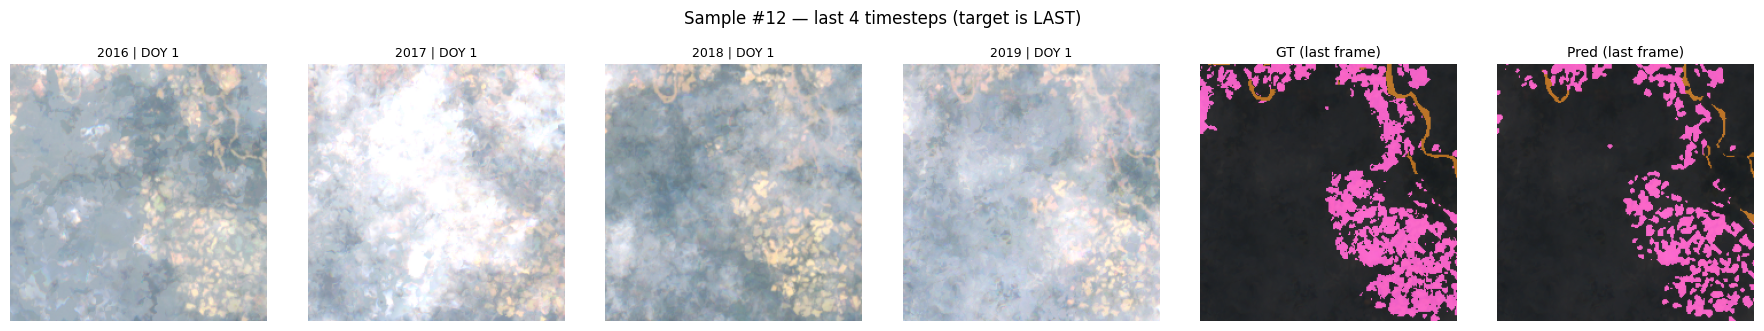

: 

In [ ]:
DEFAULT_ENCODING = {
    3: [255, 255,   0],  # yellow
    2: [180,  96,   0],  # brown-ish
    1: [251,  72, 196],  # magenta
    0: [  0,   0,   0],  # background
}

visualise_random_prediction_temporal(
    model,
    dataset=val_dataset,     # your MineFootprintTFRecordDataset with temporal stacks
    timesteps=TIMESTEPS,            # pick the last 4 frames; change as you wish
    device=device,
    colour_encoding=DEFAULT_ENCODING,
    rgb_divisor=3000.0,
    alpha=0.8,
    rgb_indices=(2,1,0),     # (R,G,B) from [BLUE,GREEN,RED,...]
)
